## 1 — Baseline (Naive Disaggregation)
Raw survey state means with no modelling — lower bound on estimate quality.  
Output: `outputs/estimates/baseline_state_estimates.csv`

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR   = Path("../test_data/processed/")
OUTPUT_DIR = Path("../outputs/")
OUTCOME    = "happening_bin"
MODEL_NAME = "baseline"

STATE_NAMES = {
    "01":"Alabama","02":"Alaska","04":"Arizona","05":"Arkansas","06":"California",
    "08":"Colorado","09":"Connecticut","10":"Delaware","11":"District of Columbia",
    "12":"Florida","13":"Georgia","15":"Hawaii","16":"Idaho","17":"Illinois",
    "18":"Indiana","19":"Iowa","20":"Kansas","21":"Kentucky","22":"Louisiana",
    "23":"Maine","24":"Maryland","25":"Massachusetts","26":"Michigan",
    "27":"Minnesota","28":"Mississippi","29":"Missouri","30":"Montana",
    "31":"Nebraska","32":"Nevada","33":"New Hampshire","34":"New Jersey",
    "35":"New Mexico","36":"New York","37":"North Carolina","38":"North Dakota",
    "39":"Ohio","40":"Oklahoma","41":"Oregon","42":"Pennsylvania",
    "44":"Rhode Island","45":"South Carolina","46":"South Dakota",
    "47":"Tennessee","48":"Texas","49":"Utah","50":"Vermont",
    "51":"Virginia","53":"Washington","54":"West Virginia","55":"Wisconsin",
    "56":"Wyoming",
}

In [2]:
survey = pd.read_csv(DATA_DIR / "climate_survey_responses_recoded.csv",
                     dtype={"state_fips": str})
survey = survey.dropna(subset=[OUTCOME]).copy()
survey[OUTCOME] = survey[OUTCOME].astype(float)
print(f"Respondents (non-DK): {len(survey):,}  ({survey[OUTCOME].mean()*100:.1f}% Yes)")

Respondents (non-DK): 1,010  (68.1% Yes)


In [3]:
# Raw weighted state means (unweighted — no ACS poststratification)
state_stats = (
    survey.groupby("state_fips")[OUTCOME]
    .agg(estimate="mean", n_respondents="count")
    .reset_index()
)

all_states = pd.DataFrame({
    "state_fips": list(STATE_NAMES.keys()),
    "state_name": list(STATE_NAMES.values()),
})
estimates = all_states.merge(state_stats, on="state_fips", how="left")
estimates["n_respondents"] = estimates["n_respondents"].fillna(0).astype(int)
estimates = estimates.sort_values("estimate", ascending=False).reset_index(drop=True)

n_valid = estimates["estimate"].notna().sum()
n_nan   = estimates["estimate"].isna().sum()
print(f"States with estimates: {n_valid}  |  no respondents (NaN): {n_nan}")
valid = estimates.dropna(subset=["estimate"])
print(f"Estimate range: [{valid['estimate'].min():.4f}, {valid['estimate'].max():.4f}]")
print(f"National mean:  {valid['estimate'].mean():.4f}")

States with estimates: 51  |  no respondents (NaN): 0
Estimate range: [0.3077, 1.0000]
National mean:  0.6602


In [4]:
# Save estimates
est_dir  = OUTPUT_DIR / "estimates"
diag_dir = OUTPUT_DIR / "diagnostics"
est_dir.mkdir(parents=True, exist_ok=True)
diag_dir.mkdir(parents=True, exist_ok=True)

out_path = est_dir / f"{MODEL_NAME}_state_estimates.csv"
estimates.to_csv(out_path, index=False)
print(f"Saved → {out_path}")

# Diagnostic text
diag_path = diag_dir / f"{MODEL_NAME}_summary.txt"
with open(diag_path, "w") as f:
    f.write("Baseline (Naive Disaggregation) — Diagnostic Summary\n")
    f.write("=" * 55 + "\n\n")
    f.write(f"Outcome variable: {OUTCOME}\n")
    f.write(f"Total respondents (non-DK): {len(survey):,}\n")
    f.write(f"States with estimates: {n_valid}\n")
    f.write(f"States with NaN: {n_nan}\n\n")
    f.write(f"Mean estimate:   {valid['estimate'].mean():.4f}\n")
    f.write(f"Median estimate: {valid['estimate'].median():.4f}\n")
    f.write(f"Min estimate:    {valid['estimate'].min():.4f}\n")
    f.write(f"Max estimate:    {valid['estimate'].max():.4f}\n\n")
    f.write("State-level estimates:\n")
    f.write(estimates.to_string(index=False))
print(f"Diagnostics → {diag_path}")

Saved → ../outputs/estimates/baseline_state_estimates.csv
Diagnostics → ../outputs/diagnostics/baseline_summary.txt


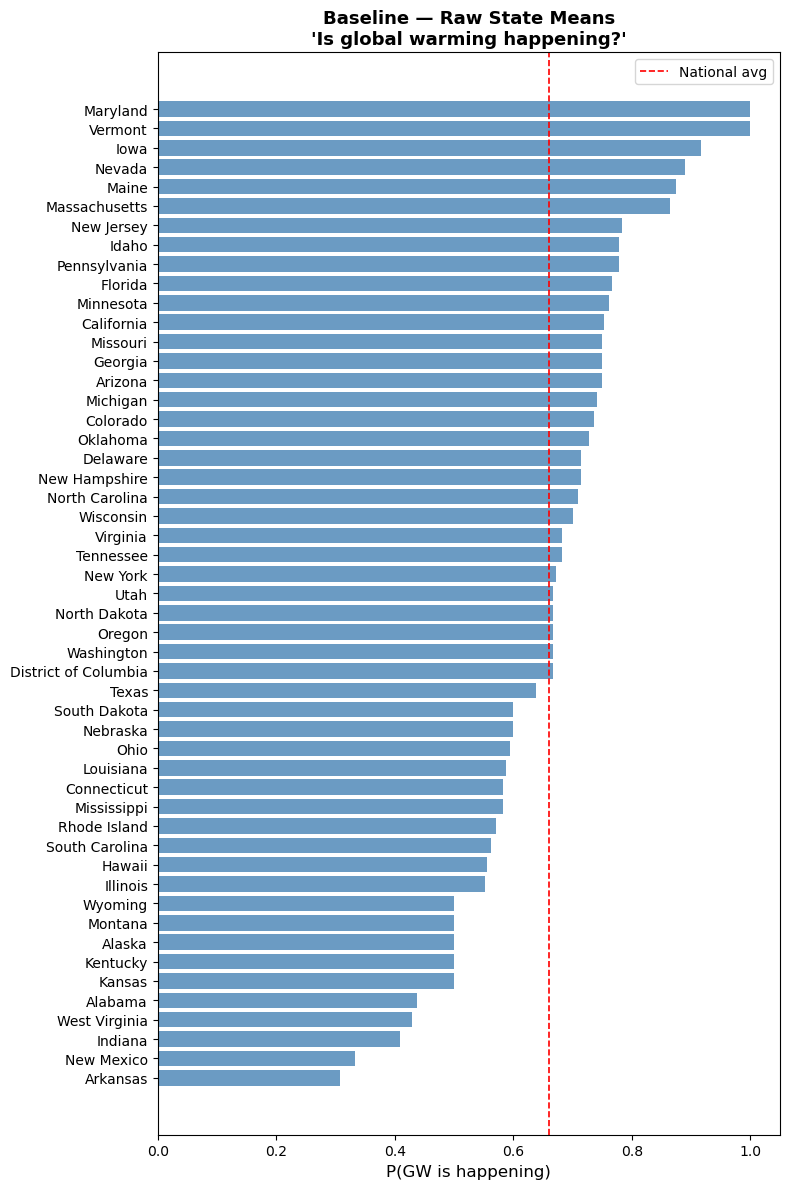

In [5]:
fig, ax = plt.subplots(figsize=(8, 12))
plot_df = valid.sort_values("estimate")
ax.barh(plot_df["state_name"], plot_df["estimate"], color="steelblue", alpha=0.8)
ax.axvline(valid["estimate"].mean(), color="red", linestyle="--", linewidth=1.2, label="National avg")
ax.set_xlabel("P(GW is happening)", fontsize=12)
ax.set_title("Baseline — Raw State Means\n'Is global warming happening?'", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(est_dir / f"{MODEL_NAME}_state_estimates.png", dpi=150, bbox_inches="tight")
plt.show()